# 第5章  函数


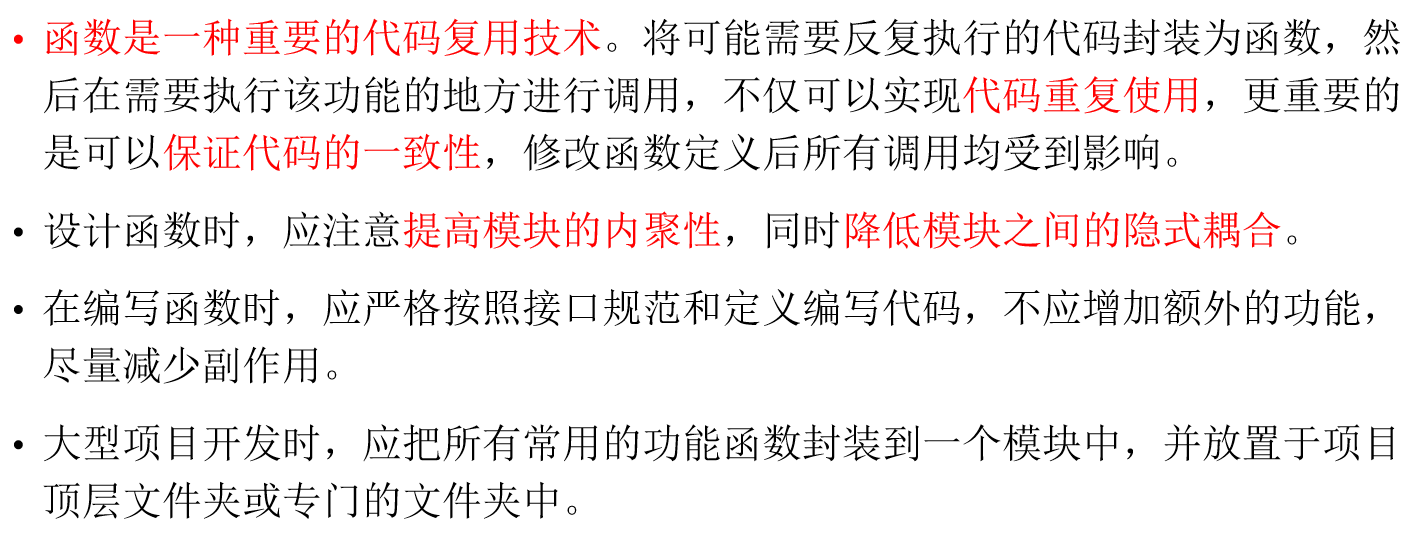

# 5.1.1  函数定义与调用基本语法

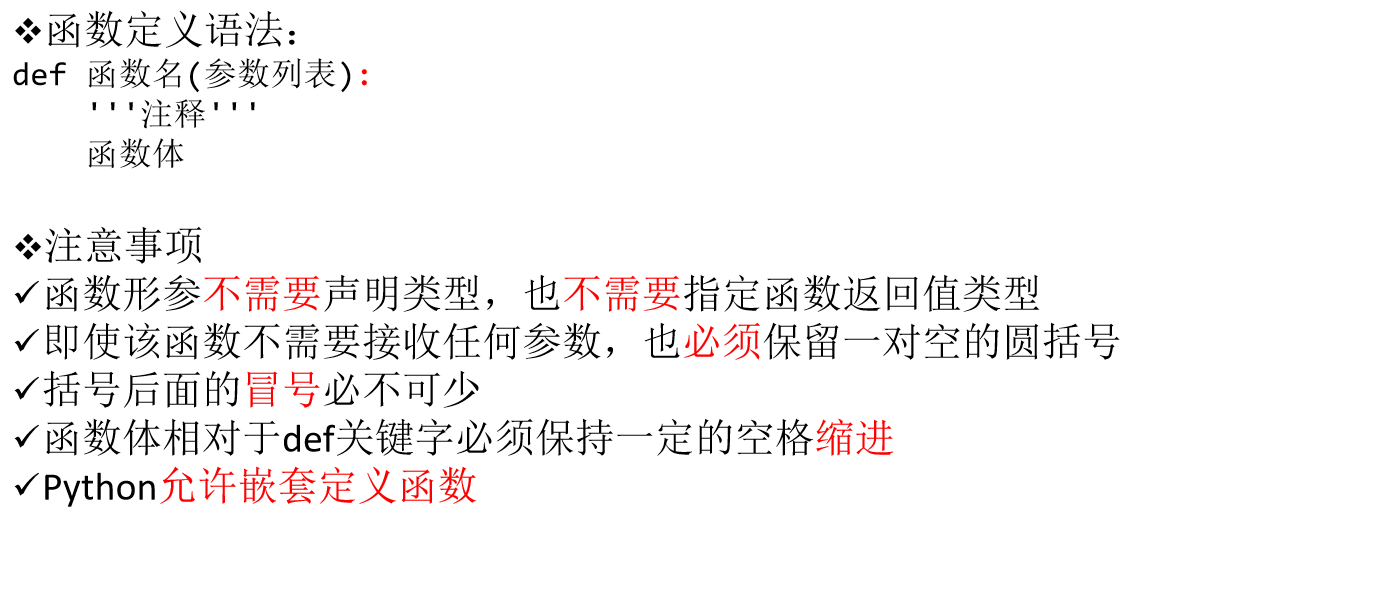
# 在定义函数时，开头部分的注释并不是必需的，但如果为函数的定义加上注释的话，可以为用户提供友好的提示

In [113]:
def num5(a):
    '''对输入的值加5'''
    b = a+5
    #return b
    a = b+5    
    return a


a = 5
num5(a)
print(a)

5


In [105]:
help(num5)

Help on function num5 in module __main__:

num5(a)
    对输入的值加5



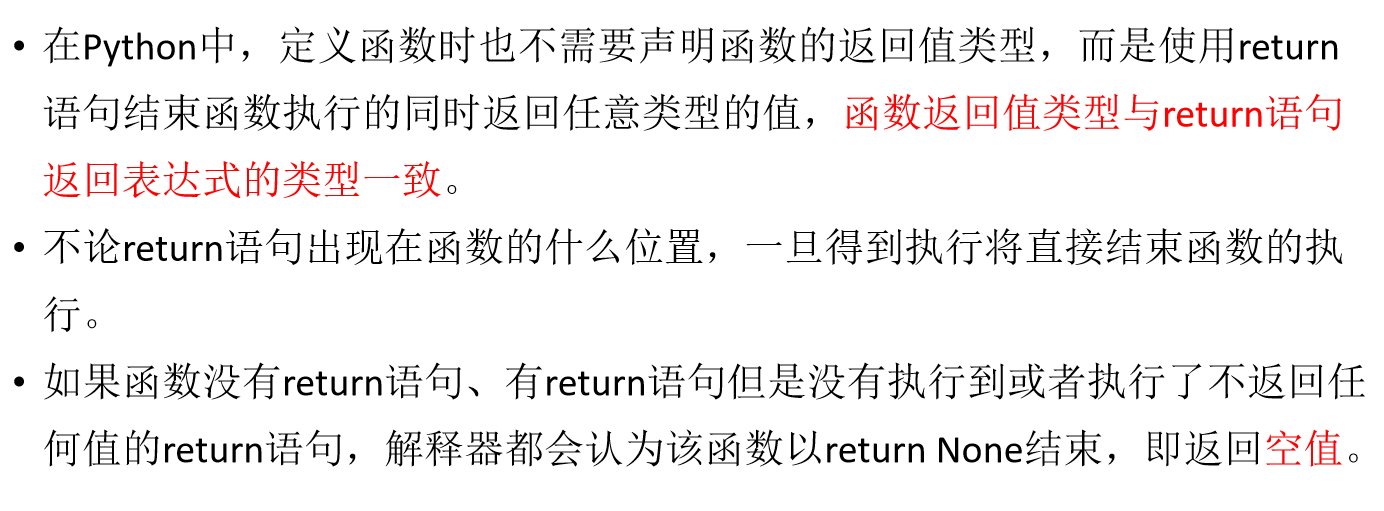

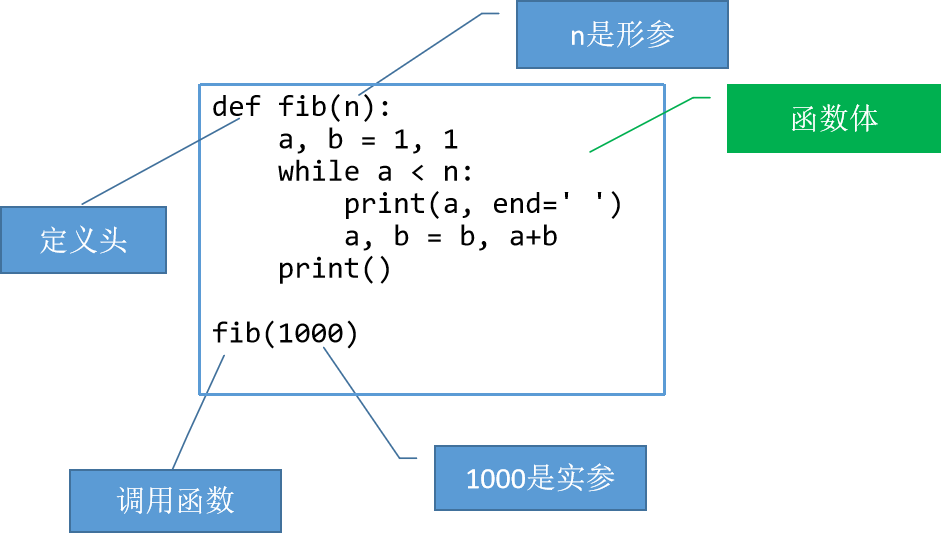

In [115]:
def fib(n):
    a, b = 1, 1
    while a < n:
        print(a, end=' ')
        a, b = b, a+b
   # print()
    return a

fib(1000)


1 1 2 3 5 8 13 21 34 55 89 144 233 377 610 987 

1597

# 5.1.2  函数嵌套定义、可调用对象与修饰器


# （1）函数嵌套定义

## Python允许函数的嵌套定义，在函数内部可以再定义另外一个函数。


In [118]:
def myMap(iterable, op, value):     #自定义函数
    if op not in '+-*/':
        return 'Error operator'
    def nested(item):                   #嵌套定义函数
        return eval(repr(item)+op+repr(value))
    return map(nested, iterable)        #使用在函数内部定义的函数


list(myMap(range(5), '+', 5)) # 调用外部函数，不需要关心其内部实现

[5, 6, 7, 8, 9]

In [8]:
help(repr)

Help on built-in function repr in module builtins:

repr(obj, /)
    Return the canonical string representation of the object.
    
    For many object types, including most builtins, eval(repr(obj)) == obj.



## str()内置函数使用 __str__ 显示对象的字符串表示形式，
## 而 repr()内置函数使用 __repr__显示对象，
## __str__是面向用户而言，
## 而__repr__是面向程序员，直接在终端打印信息方便调试。



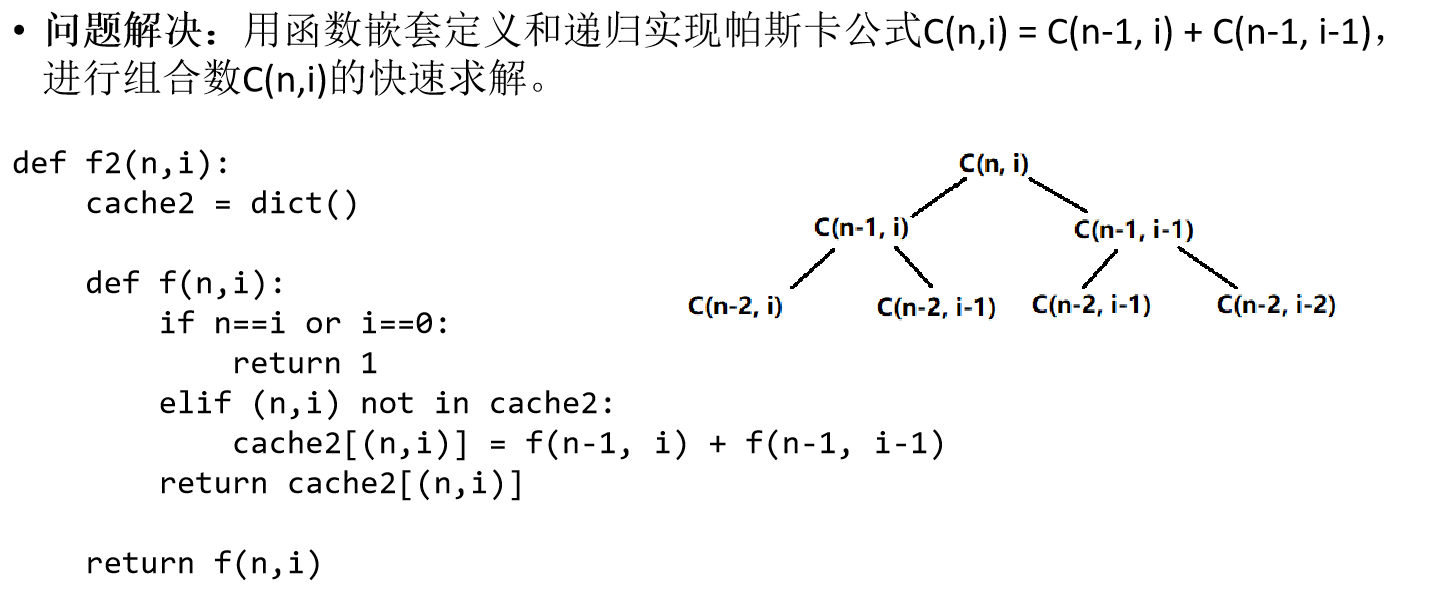

In [121]:
#return 语句就是将结果返回到调用的地方，并把程序的控制权一起返回
# return 返回的值要和函数一致
def f2(n,i):
    cache2 = dict() 
    def f(n,i):# 内部函数f可以引用外部函数f2的参数和局部变量
        if n==i or i==0:
            return 1
        elif (n,i) not in cache2:
            cache2[(n,i)] = f(n-1, i) + f(n-1, i-1)   
            print(cache2)
            
        return cache2[(n,i)]
            
    return f(n,i)  #外函数返回内函数的调用结果

f2(4,2)

{(2, 1): 2}
{(2, 1): 2, (3, 2): 3}
{(2, 1): 2, (3, 2): 3, (3, 1): 3}
{(2, 1): 2, (3, 2): 3, (3, 1): 3, (4, 2): 6}


6

In [126]:
def num1(a):
    def num2(a):
        a = a+1
        b = 1
        return a,b
    return num2(a)

num1(3)

(4, 1)

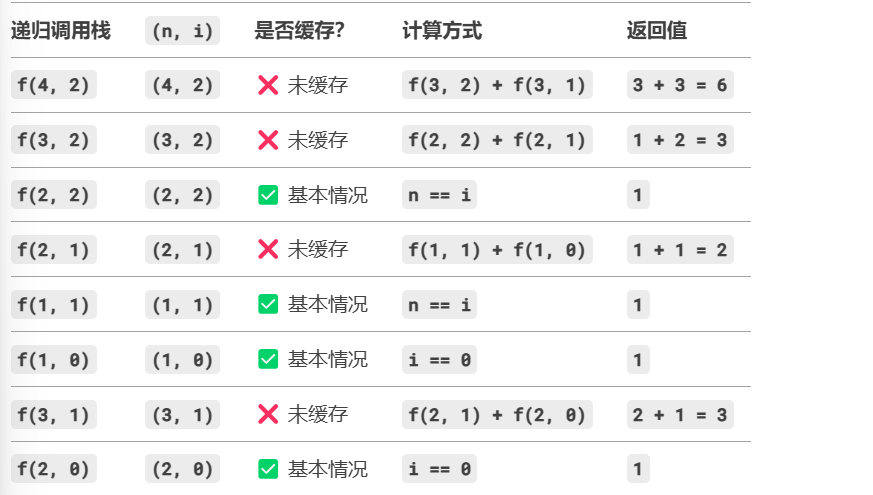

In [59]:
def f2(n, i):
    cache2 = dict()
    def f(n, i):
        if n == i or i == 0:
            return 1
        if (n, i) in cache2:  # 先检查缓存
            return cache2[(n, i)]
        # 计算并缓存结果
        cache2[(n, i)] = f(n-1, i) + f(n-1, i-1)
        return cache2[(n, i)] # 最后返回结果
    return f(n, i)

f2(4,2)

6

In [120]:
def num5(a):
    c = []
    def num(a):
        c.append(a+5)
        return c,6
    return num(a)  #当num5返回函数num时，相关参数和变量都保存在返回的函数中，这种称为“闭包（Closure）”的程序结构拥有极大的威力
    
num5(3)  

([8], 6)

# （2）可调用对象

## 函数属于Python可调用对象之一，由于构造方法的存在，类也是可调用的。像list()、tuple()、dict()、set()这样的工厂函数实际上都是调用了类的构造方法。另外，任何包含__call__()方法的类的对象也是可调用的。


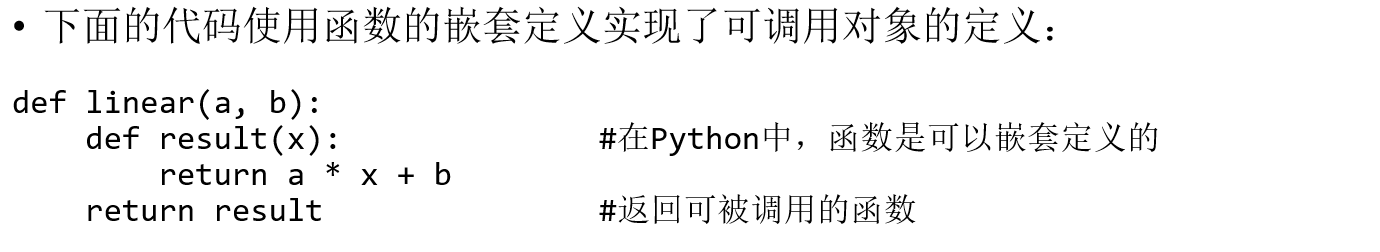

In [19]:
def linear(a, b):
    def result(x):              #在Python中，函数是可以嵌套定义的
        return a * x + b
    return result  #返回可被调用的函数

linear(3,4)(2)

10

In [3]:
def linear(a, b):
    def result(x):              #在Python中，函数是可以嵌套定义的
        return a * x + b
    return result(2)  #返回可被调用的函数值

linear(3,4)

10

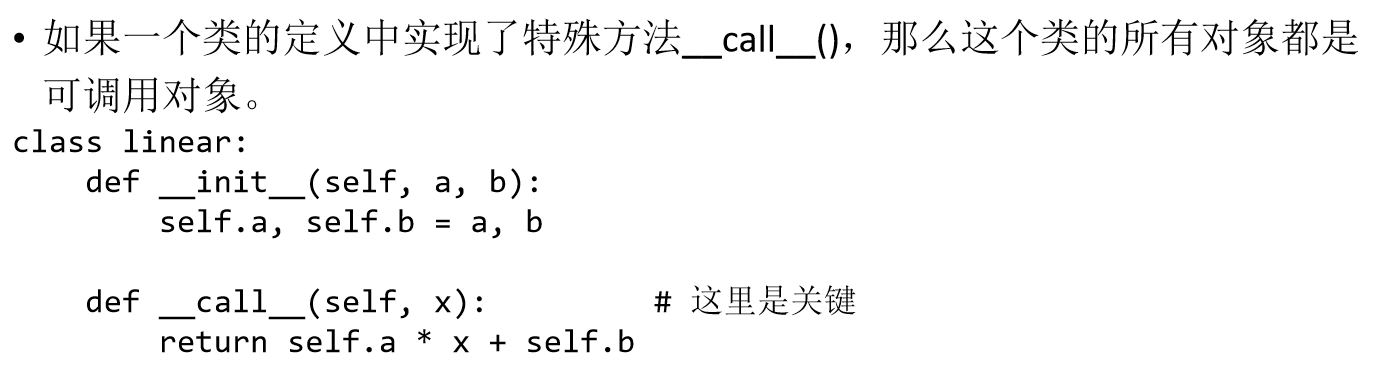

In [79]:
class linear:
    def __init__(self, a, b):
        self.a, self.b = a, b

    def __call__(self, x):         # 这里是关键
        return self.a * x + self.b

# 创建一个实例对象
example = linear(3,4)
example(2)

10

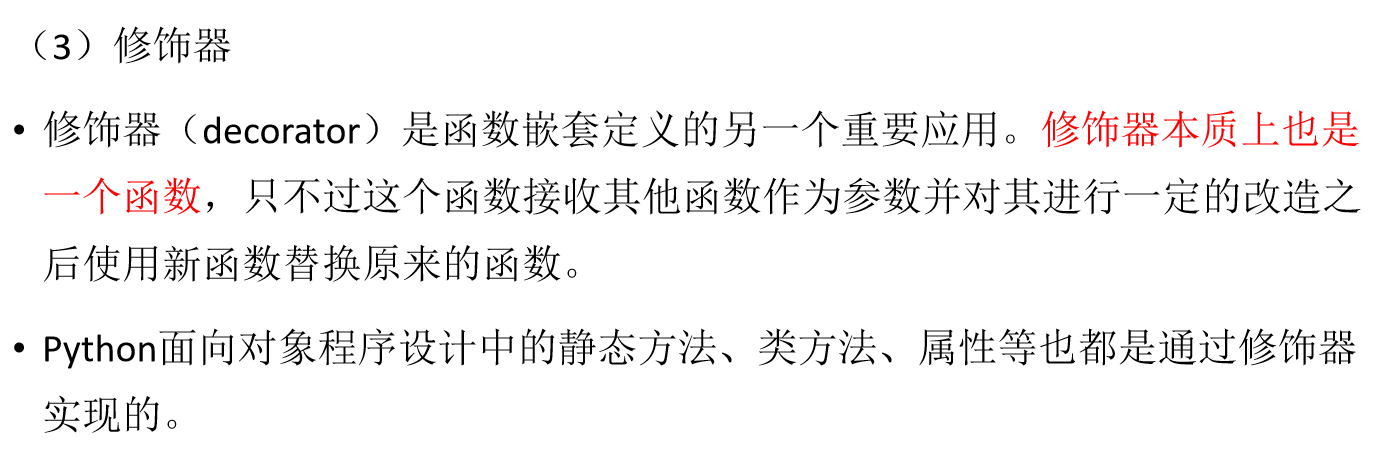

In [26]:
def my_decorator(func):
    def wrapper():
        print("Something is happening before the function is called.")
        func()
        print("Something is happening after the function is called.")
    return wrapper

def say_whee():
    print("Whee!")

say_whee = my_decorator(say_whee)
say_whee()

Something is happening before the function is called.
Whee!
Something is happening after the function is called.


In [24]:
@my_decorator
def say_whee():
    print("Whee!")
    
say_whee()    

Something is happening before the function is called.
Whee!
Something is happening after the function is called.


# 5.1.3  函数递归调用


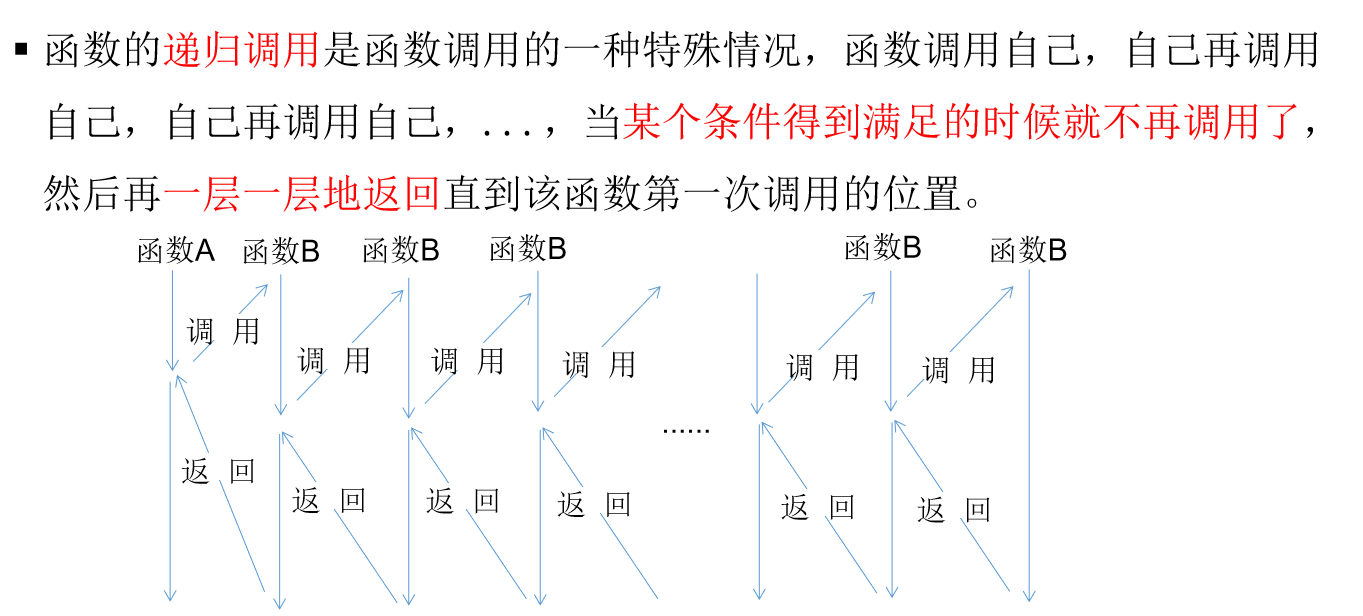

In [80]:
# 问题解决：使用递归法对整数进行因数分解。
from random import randint

def factors(num, fac=[]):
    #每次都从2开始查找因数
    for i in range(2, int(num**0.5)+1):
        #找到一个因数
        if num%i == 0:
            fac.append(i)
            #对商继续分解，重复这个过程
            factors(num//i, fac)
            #注意，这个break非常重要
            break
    else:
        #不可分解了，自身也是个因数
        fac.append(num)

facs = []
n = 32 #randint(2, 10**8)
factors(n, facs)
result = '*'.join(map(str, facs))
if n==eval(result):
    print(n, '= '+result)


32 = 2*2*2*2*2


In [32]:
facs

[2, 2, 2, 2, 2]

In [33]:
result

'2*2*2*2*2'

for item in iterable:
    # 循环主体
    if condition:
        break  # 如果执行了 break，else 不会执行
else:
    pass # 当 for 循环正常结束（没有 break）时执行

In [84]:
numbers = [1, 3, 5, 7, 9]
numbers = [1,2,3,4]
for num in numbers:
    if num % 2 == 0:
        print(f"找到偶数: {num}")
        break
else:
    print("没有找到偶数")  # 会执行！

找到偶数: 2


# 5.2  函数参数


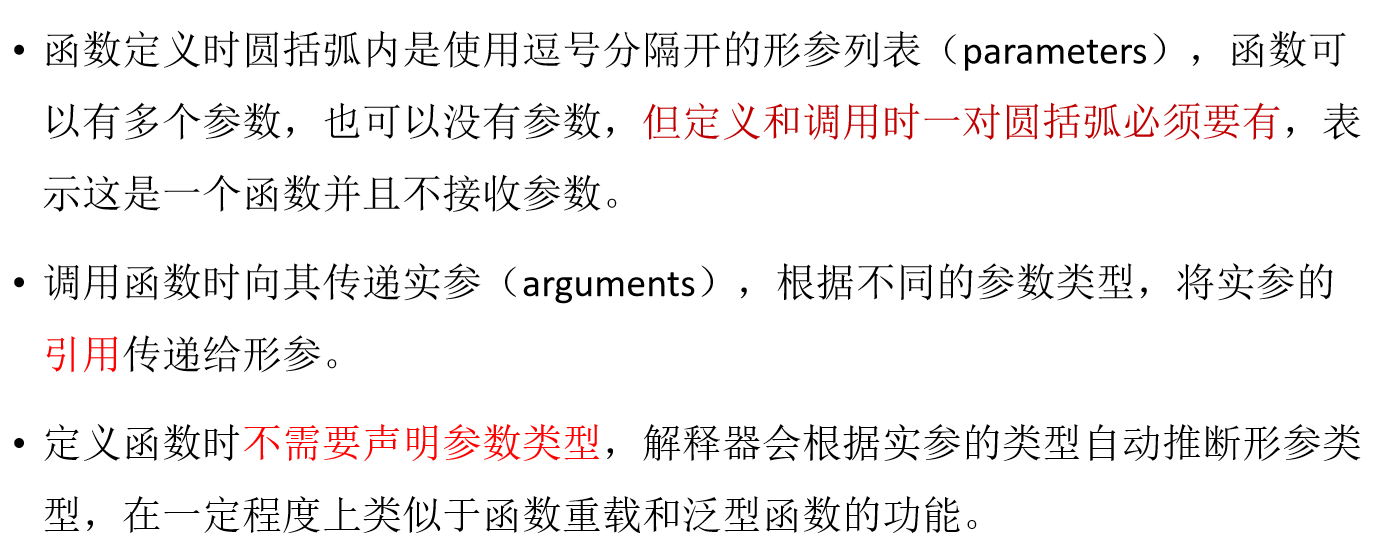

# 对于绝大多数情况下，在函数内部直接修改形参的值不会影响实参，而是创建一个新变量。

In [34]:
def add5(x):
    print(id(x))
    x = x+1
    print(id(x))
    return x
    
v = 3    
add5(v),v,id(v) 

140717111981920
140717111981952


(4, 3, 140717111981920)

# 在有些情况下，可以通过特殊的方式在函数内部修改实参的值。

In [37]:
def modify(v):          # 使用下标修改列表元素值
    v[0] = v[0]+1
    return v

a = [2]
modify(a),a


([3], [3])

In [38]:
def modify(v, item):    # 使用列表的方法为列表增加元素
    v.append(item)
    
a = [2]
modify(a,3)
a


[2, 3]

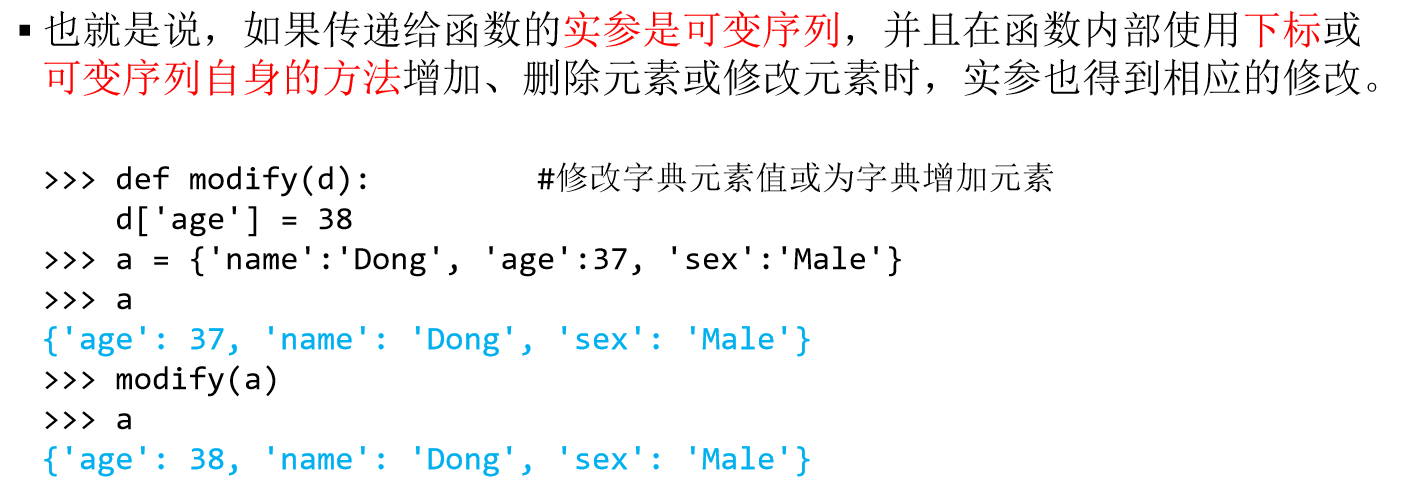

# 5.2.1  位置参数


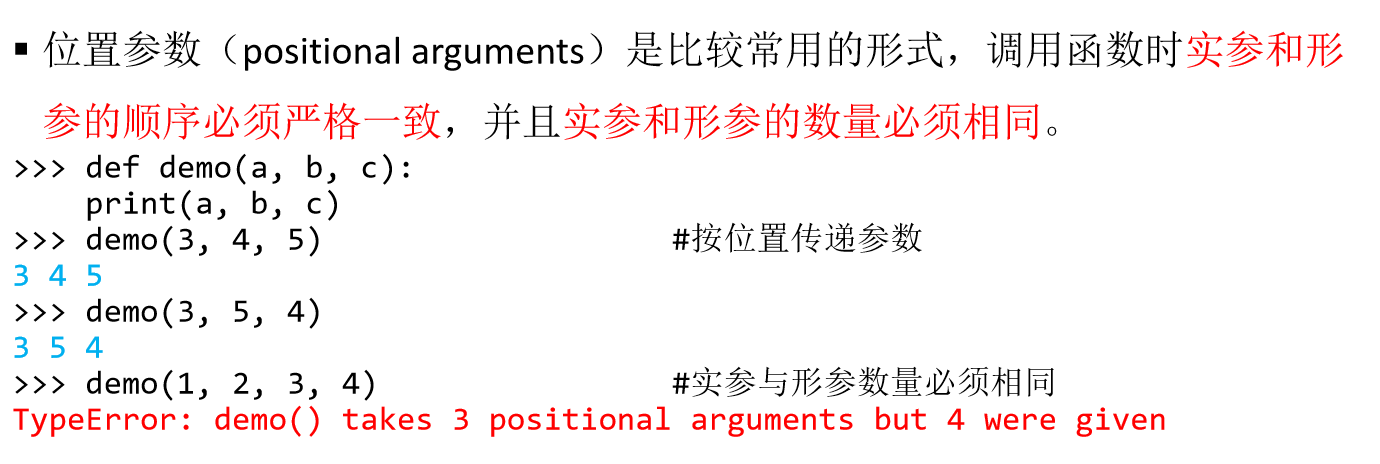

# 5.2.2  默认值参数


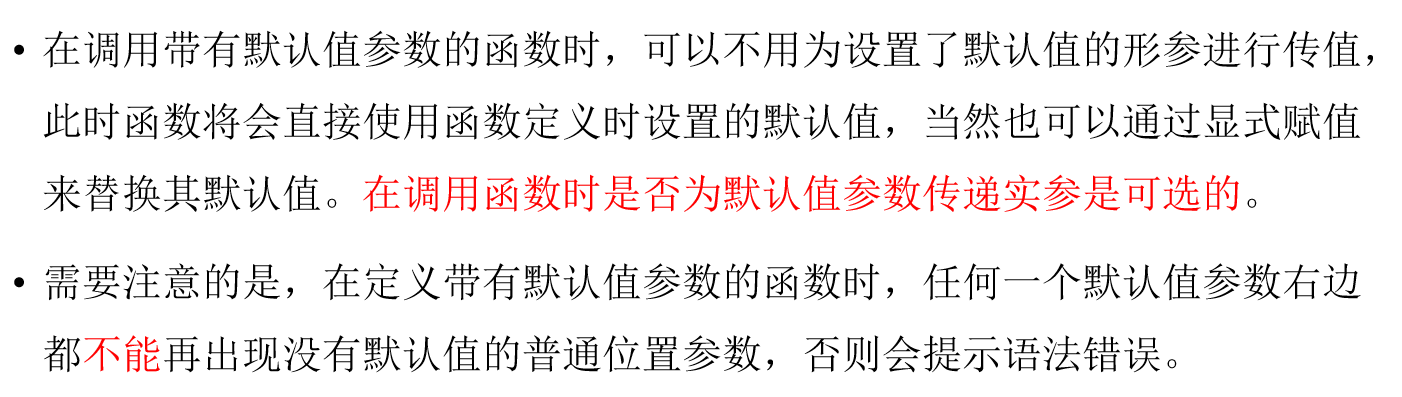

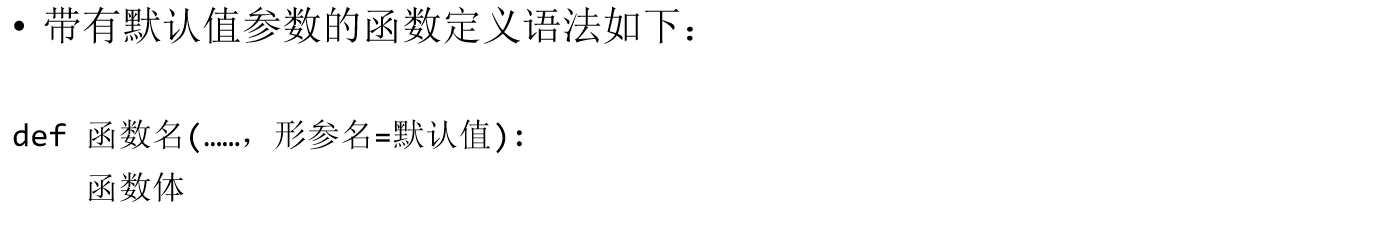

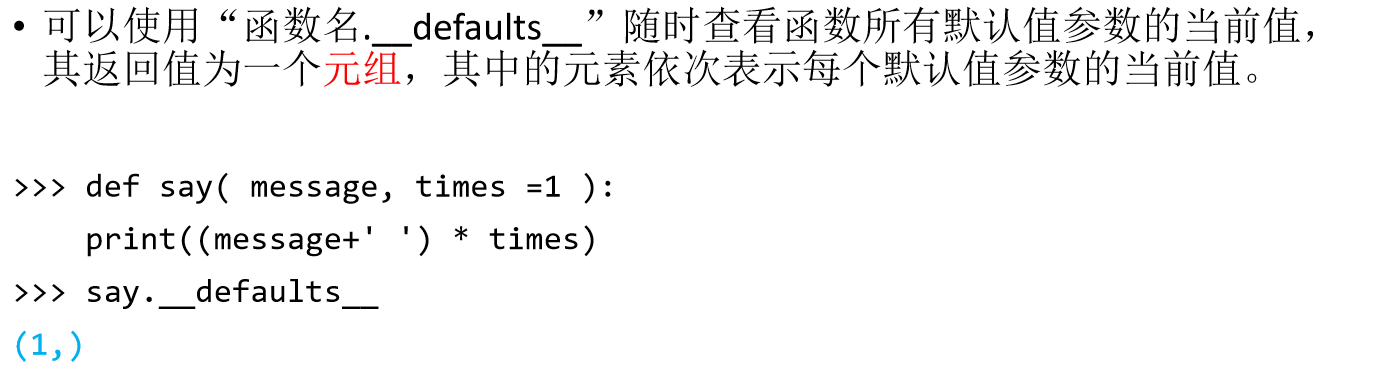

In [87]:
def add5(lst,num = 4):
    lst.append(num)
    return lst
   # pass
    
add5([1,2,3],5)
#add5.__defaults__

[1, 2, 3, 5]

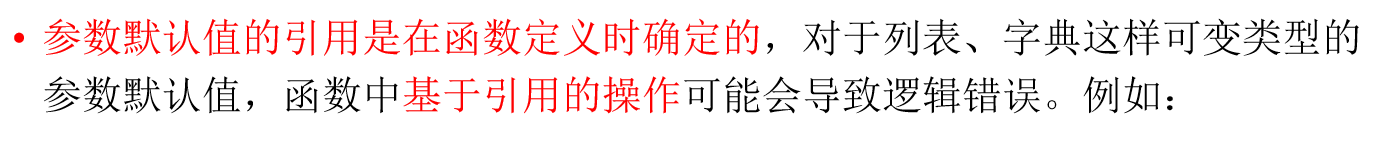

In [102]:
def foo(abc=[],d = 1,e=2):
    abc.append(200)
    print(abc)
print(foo(),id(foo))
print(foo.__defaults__)
print(foo(),id(foo))
print(foo.__defaults__)

[200]
None 2519562436176
([200], 1, 2)
[200, 200]
None 2519562436176
([200, 200], 1, 2)


In [95]:
def add1(a,b=[2,3],c=3):
    b.append(5)
    print(a,b,c)
    
add1(1)   
print(add1.__defaults__)


1 [2, 3, 5] 3
([2, 3, 5], 3)


In [96]:
add1(1,[2,4],4)  
add1.__defaults__

1 [2, 4, 5] 4


([2, 3, 5], 3)

## 一般来说，要避免使用列表、字典、集合或其他可变对象作为函数参数默认值，对于上面的函数，更建议使用下面的写法。


In [99]:
def add1(a, b=None, c=3):
    if b is None:
        b = [2, 3]  # 每次调用重新创建新列表
    b.append(5)
    print(a, b, c)      

In [100]:
def add1(a, b=(2, 3), c=3):  # 元组不可变
    b = list(b)  # 转为列表再操作
    b.append(5)
    print(a, b, c)

## 再比如

In [112]:
def demo(newitem, old_list=[]):
    old_list.append(newitem)
    return old_list

print(demo('a'))

['a']


In [113]:
print(demo('b'))

['a', 'b']


# 改进

In [115]:
def demo(newitem, old_list=None):
    if old_list is None:
        old_list = []
    old_list.append(newitem)
    return old_list

In [116]:
print(demo('a'))

['a']


In [117]:
print(demo('b'))

['b']


# 函数的默认值参数是在函数定义时确定值的，所以只会被初始化一次。


In [119]:
i = 3
def f(n=i):                 #参数n的值仅取决于i的当前值
    print(n)
f()

3


In [120]:
i=7
f()

3


# 5.2.3  关键参数


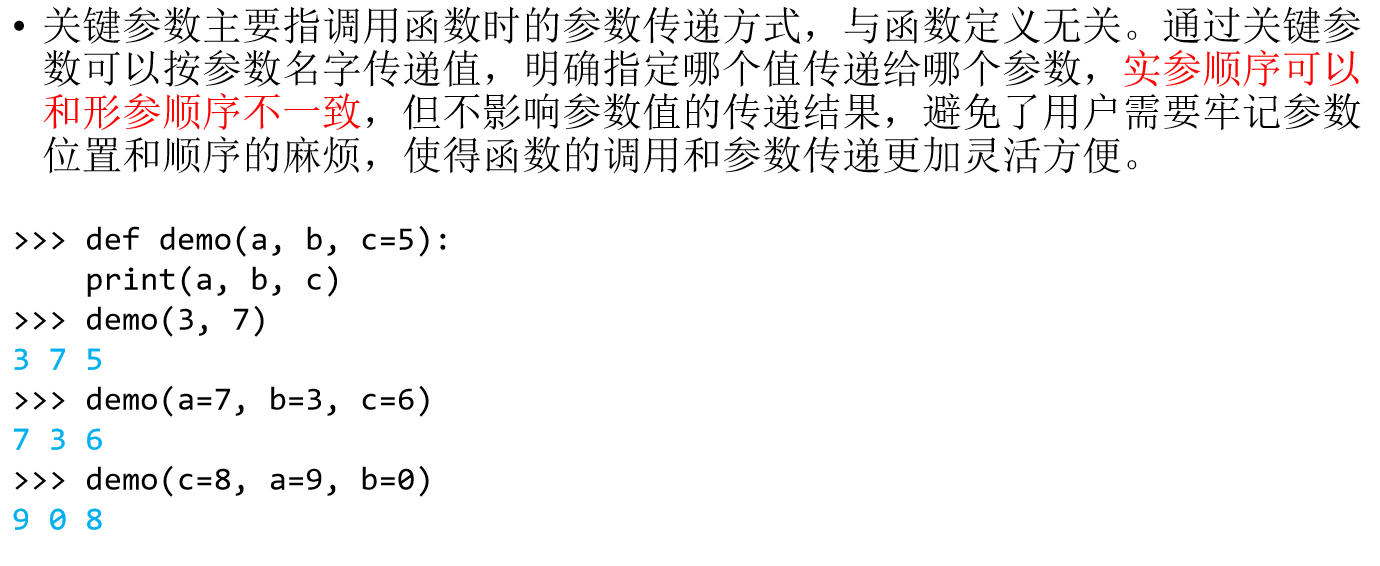

# 5.2.4  可变长度参数


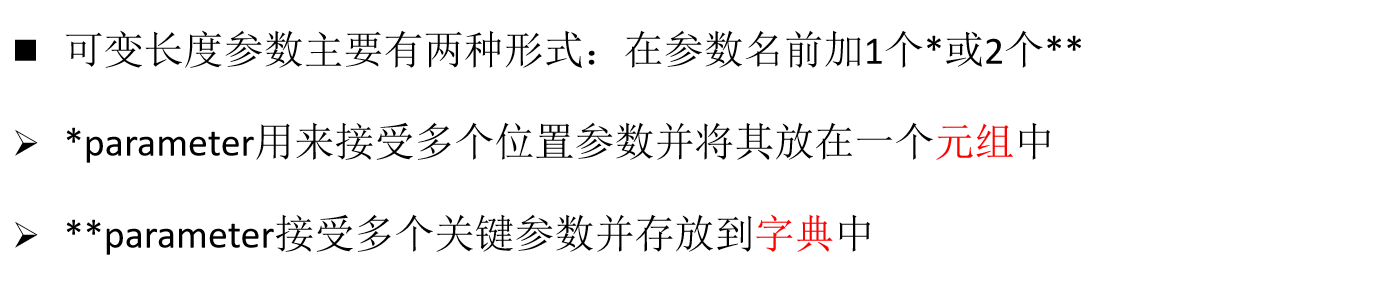

# *parameter的用法


In [121]:
def demo(*p):
    print(p)

demo(1,2,3)    

(1, 2, 3)


# **parameter的用法


In [122]:
 def demo(**p):
    for item in p.items():
        print(item)

demo(x=1,y=2,z=3)       

('x', 1)
('y', 2)
('z', 3)


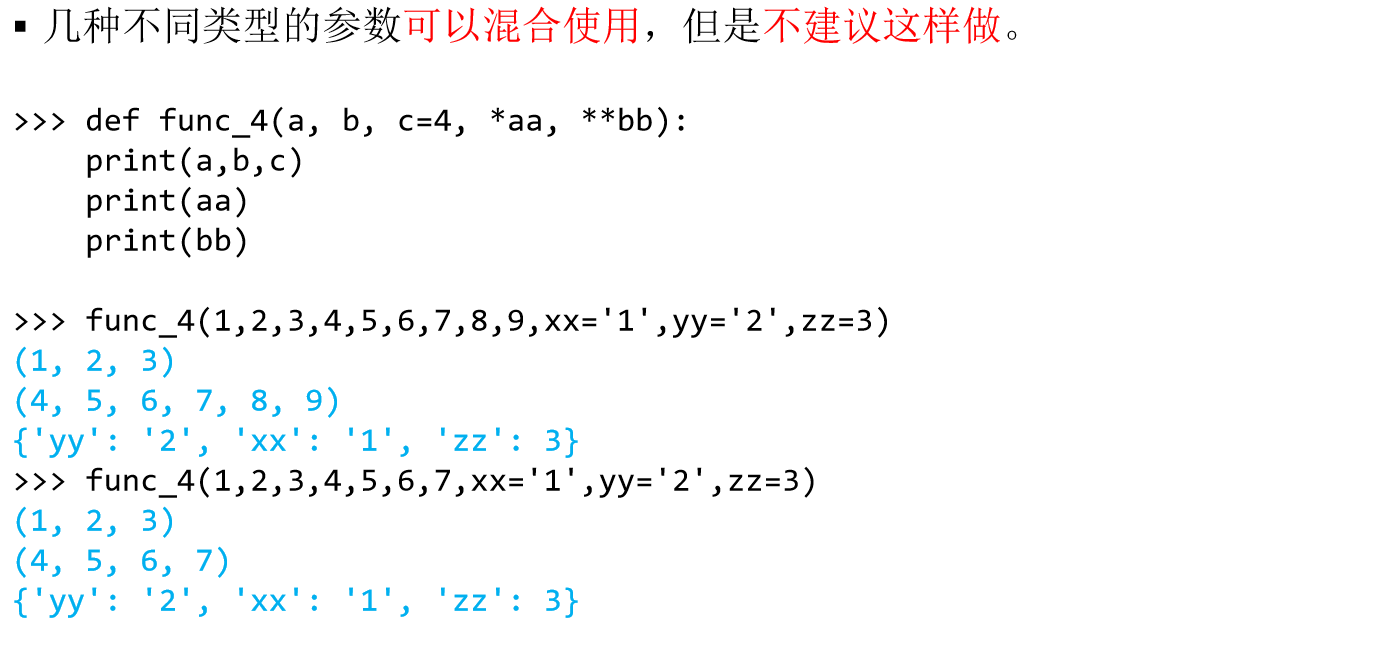